# LAB 1 - Izhikevich Dynamics

This notebook reproduces the mandatory set of Izhikevich neuron behaviors (A-T) with a fresh implementation.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from izhikevich_tools import (
    IzhikevichConfig,
    linear_ramp,
    rectangular_pulse,
    pulse_train,
    save_trace_plots,
    simulate,
)


In [2]:
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def const_after(t0, amp, baseline=0.0):
    return lambda t: amp if t > t0 else baseline


def window_pulse(t0, duration, amp, baseline=0.0):
    return lambda t: amp if (t0 <= t <= t0 + duration) else baseline


## Define all assignments (A-T)


In [3]:
experiments = {
    "A": {
        "title": "(A) tonic spiking",
        "cfg": IzhikevichConfig(a=0.02, b=0.2, c=-65, d=6, v0=-70),
        "current": const_after(10, 14),
        "kwargs": {"t_stop": 100, "dt": 0.25},
    },
    "B": {
        "title": "(B) phasic spiking",
        "cfg": IzhikevichConfig(a=0.02, b=0.25, c=-65, d=6, v0=-64),
        "current": const_after(20, 0.5),
        "kwargs": {"t_stop": 200, "dt": 0.25},
    },
    "C": {
        "title": "(C) tonic bursting",
        "cfg": IzhikevichConfig(a=0.02, b=0.2, c=-50, d=2, v0=-70),
        "current": const_after(20, 15),
        "kwargs": {"t_stop": 220, "dt": 0.25},
    },
    "D": {
        "title": "(D) phasic bursting",
        "cfg": IzhikevichConfig(a=0.02, b=0.25, c=-55, d=0.05, v0=-64),
        "current": const_after(20, 0.6),
        "kwargs": {"t_stop": 200, "dt": 0.2},
    },
    "E": {
        "title": "(E) mixed mode",
        "cfg": IzhikevichConfig(a=0.02, b=0.2, c=-55, d=4, v0=-70),
        "current": const_after(16, 10),
        "kwargs": {"t_stop": 160, "dt": 0.25},
    },
    "F": {
        "title": "(F) spike frequency adaptation",
        "cfg": IzhikevichConfig(a=0.01, b=0.2, c=-65, d=8, v0=-70),
        "current": const_after(8, 30),
        "kwargs": {"t_stop": 85, "dt": 0.25},
    },
    "G": {
        "title": "(G) class 1 excitability",
        "cfg": IzhikevichConfig(a=0.02, b=-0.1, c=-55, d=6, v0=-60, k_v=4.1, k_0=108),
        "current": linear_ramp(after=30, slope=0.075, intercept_before=0.0),
        "kwargs": {"t_stop": 300, "dt": 0.25},
    },
    "H": {
        "title": "(H) class 2 excitability",
        "cfg": IzhikevichConfig(a=0.2, b=0.26, c=-65, d=0, v0=-64),
        "current": linear_ramp(after=30, slope=0.015, intercept_before=-0.5),
        "kwargs": {"t_stop": 300, "dt": 0.25},
    },
    "I": {
        "title": "(I) spike latency",
        "cfg": IzhikevichConfig(a=0.02, b=0.2, c=-65, d=6, v0=-70),
        "current": window_pulse(10, 3, 7.04),
        "kwargs": {"t_stop": 100, "dt": 0.2},
    },
    "J": {
        "title": "(J) subthreshold oscillations",
        "cfg": IzhikevichConfig(a=0.05, b=0.26, c=-60, d=0, v0=-62),
        "current": window_pulse(20, 5, 2),
        "kwargs": {"t_stop": 200, "dt": 0.25},
    },
    "K": {
        "title": "(K) resonator",
        "cfg": IzhikevichConfig(a=0.1, b=0.26, c=-60, d=-1, v0=-62),
        "current": pulse_train([(40, 44), (60, 64), (280, 284), (320, 324)], amplitude=0.65, baseline=0.0),
        "kwargs": {"t_stop": 400, "dt": 0.25},
    },
    "L": {
        "title": "(L) integrator",
        "cfg": IzhikevichConfig(a=0.02, b=-0.1, c=-55, d=6, v0=-60, k_v=4.1, k_0=108),
        "current": pulse_train([(9, 11), (14, 16), (70, 72), (80, 82)], amplitude=9, baseline=0.0),
        "kwargs": {"t_stop": 100, "dt": 0.25},
    },
    "M": {
        "title": "(M) rebound spike",
        "cfg": IzhikevichConfig(a=0.03, b=0.25, c=-60, d=4, v0=-64),
        "current": window_pulse(20, 5, -15),
        "kwargs": {"t_stop": 200, "dt": 0.2},
    },
    "N": {
        "title": "(N) rebound burst",
        "cfg": IzhikevichConfig(a=0.03, b=0.25, c=-52, d=0, v0=-64),
        "current": window_pulse(20, 5, -15),
        "kwargs": {"t_stop": 200, "dt": 0.2},
    },
    "O": {
        "title": "(O) threshold variability",
        "cfg": IzhikevichConfig(a=0.03, b=0.25, c=-60, d=4, v0=-64),
        "current": lambda t: 1.0 if (10 < t < 15) or (80 < t < 85) else (-6.0 if 70 < t < 75 else 0.0),
        "kwargs": {"t_stop": 100, "dt": 0.25},
    },
    "P": {
        "title": "(P) bistability",
        "cfg": IzhikevichConfig(a=0.1, b=0.26, c=-60, d=0, v0=-61),
        "current": lambda t: 1.24 if (37.5 <= t <= 42.5) or (216 <= t <= 221) else 0.24,
        "kwargs": {"t_stop": 300, "dt": 0.25},
    },
    "Q": {
        "title": "(Q) depolarizing after-potential",
        "cfg": IzhikevichConfig(a=1.0, b=0.2, c=-60, d=-21, v0=-70),
        "current": lambda t: 20 if abs(t - 10) < 1 else 0,
        "kwargs": {"t_stop": 50, "dt": 0.1},
    },
    "R": {
        "title": "(R) accommodation",
        "cfg": IzhikevichConfig(a=0.02, b=1.0, c=-55, d=4, v0=-65, u0=-16),
        "current": lambda t: (t / 25.0) if t < 200 else (0.0 if t < 300 or t >= 312.5 else (t - 300) / 12.5 * 4.0),
        "kwargs": {"t_stop": 400, "dt": 0.5, "recovery_mode": "accommodation"},
    },
    "S": {
        "title": "(S) inhibition-induced spiking",
        "cfg": IzhikevichConfig(a=-0.02, b=-1.0, c=-60, d=8, v0=-63.8),
        "current": lambda t: 80 if (t < 50 or t > 250) else 75,
        "kwargs": {"t_stop": 350, "dt": 0.5},
    },
    "T": {
        "title": "(T) inhibition-induced bursting",
        "cfg": IzhikevichConfig(a=-0.026, b=-1.0, c=-45, d=-2, v0=-63.8),
        "current": lambda t: 80 if (t < 50 or t > 250) else 75,
        "kwargs": {"t_stop": 350, "dt": 0.5},
    },
}


## Run all experiments


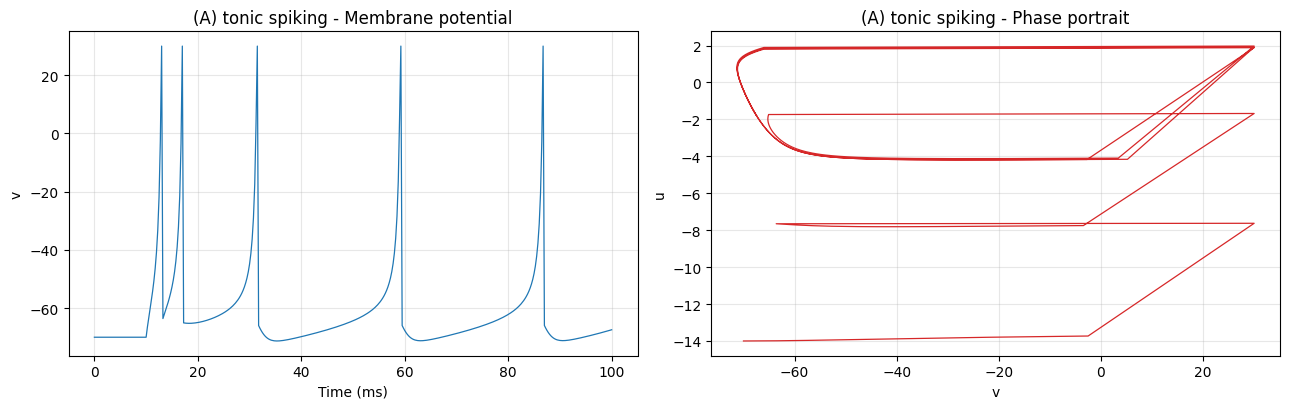

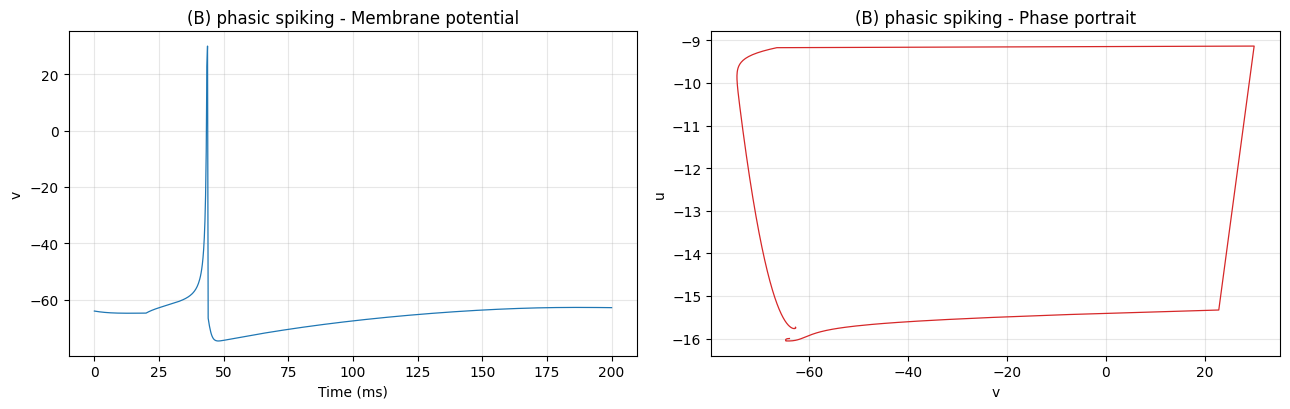

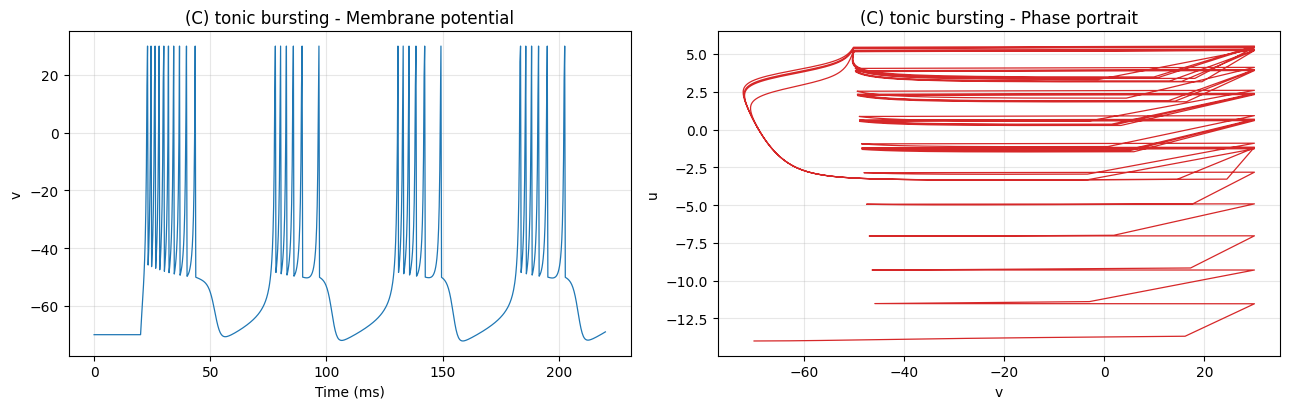

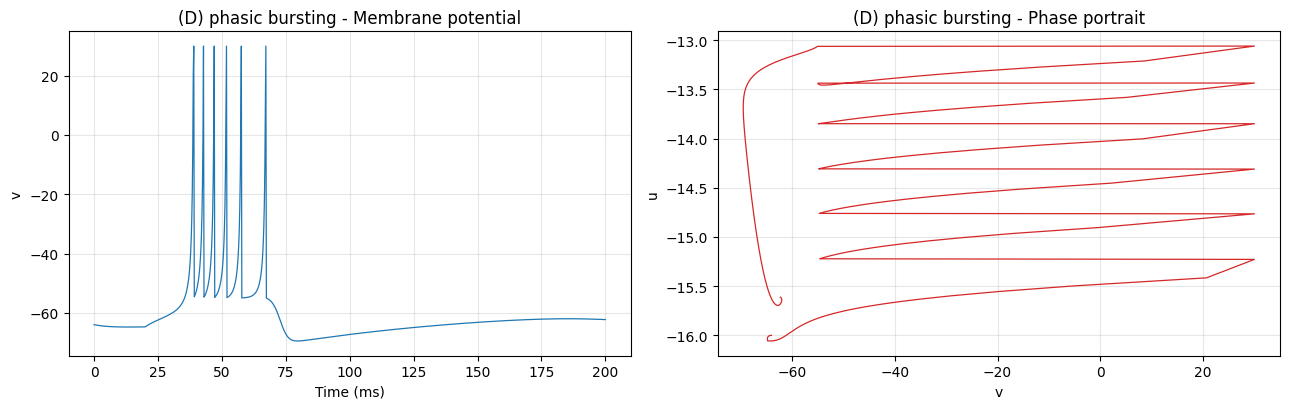

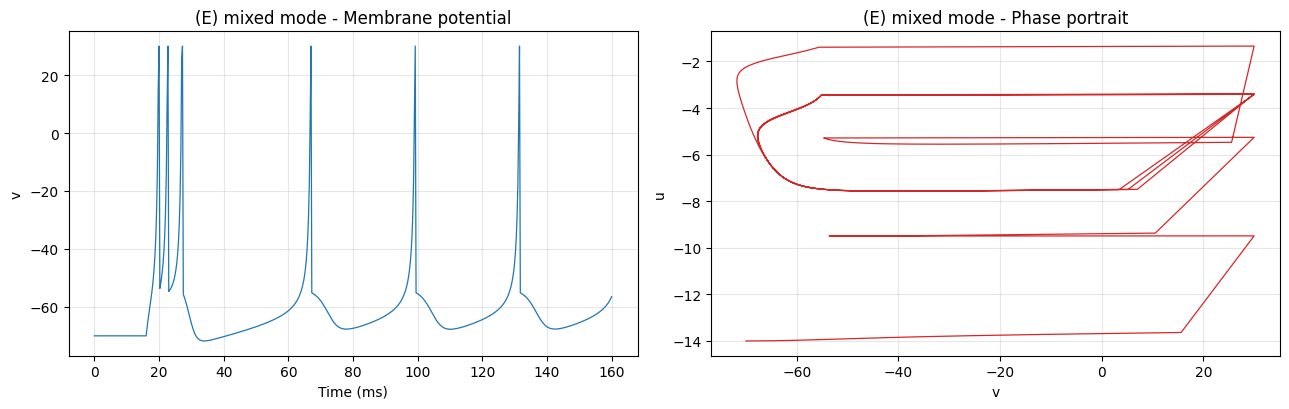

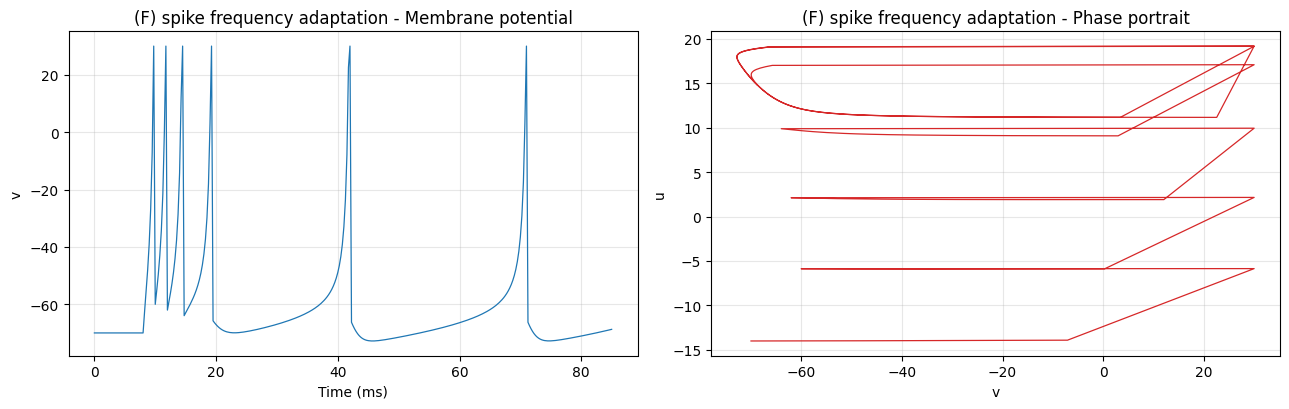

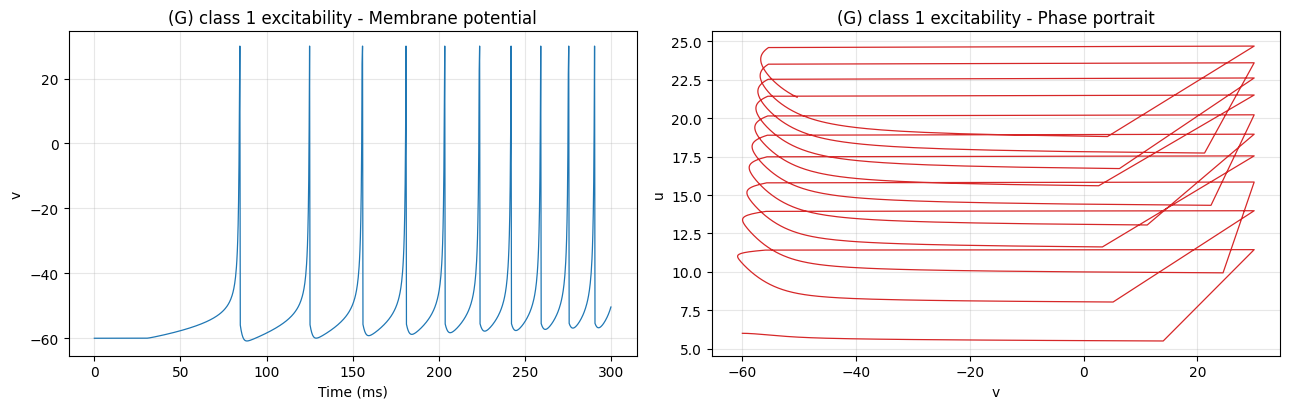

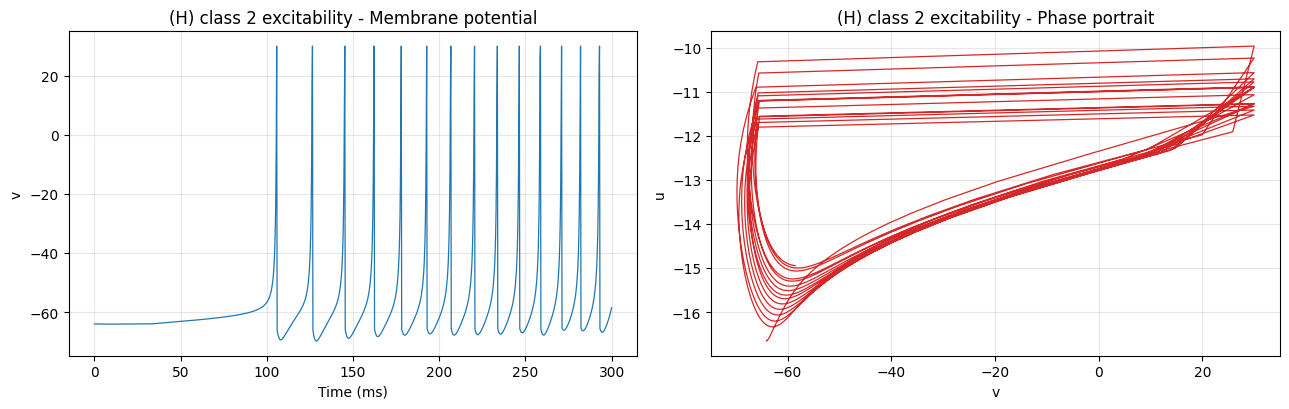

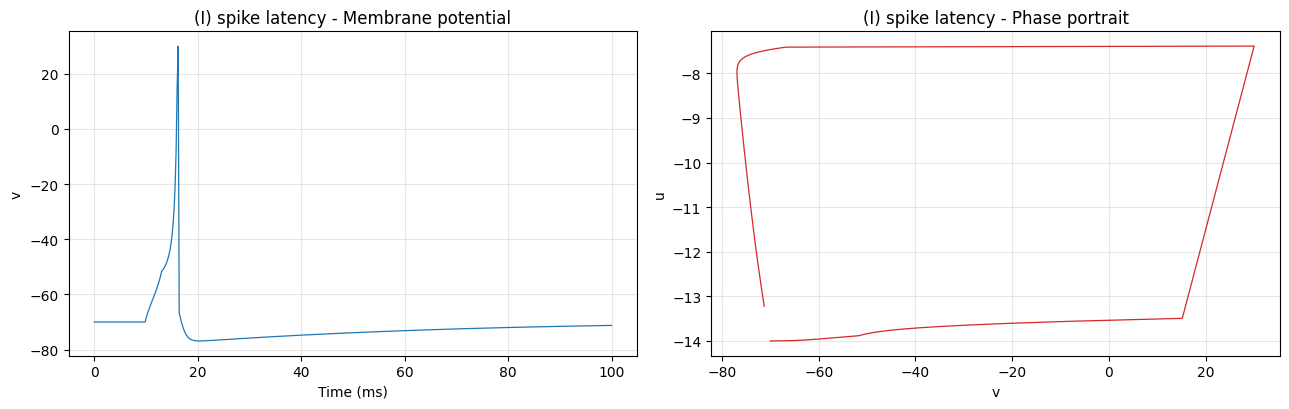

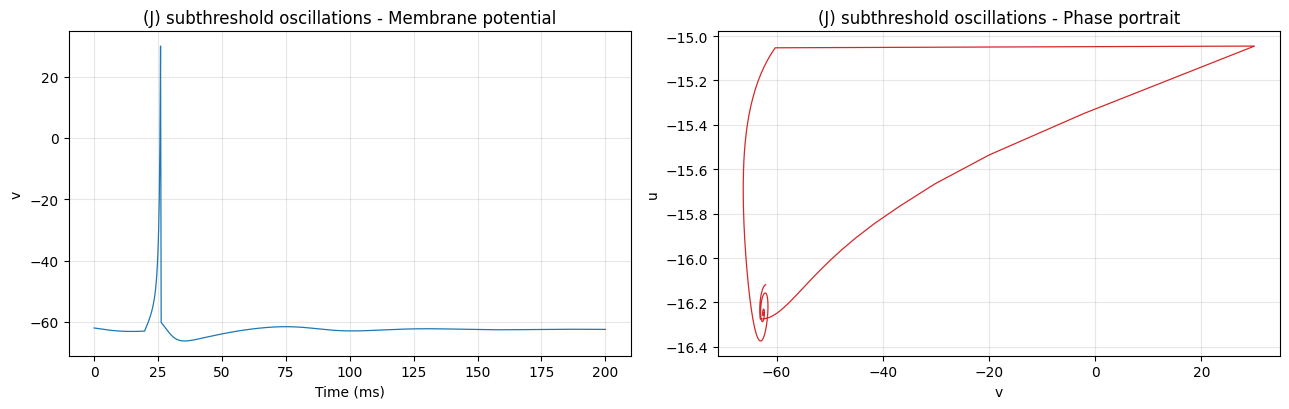

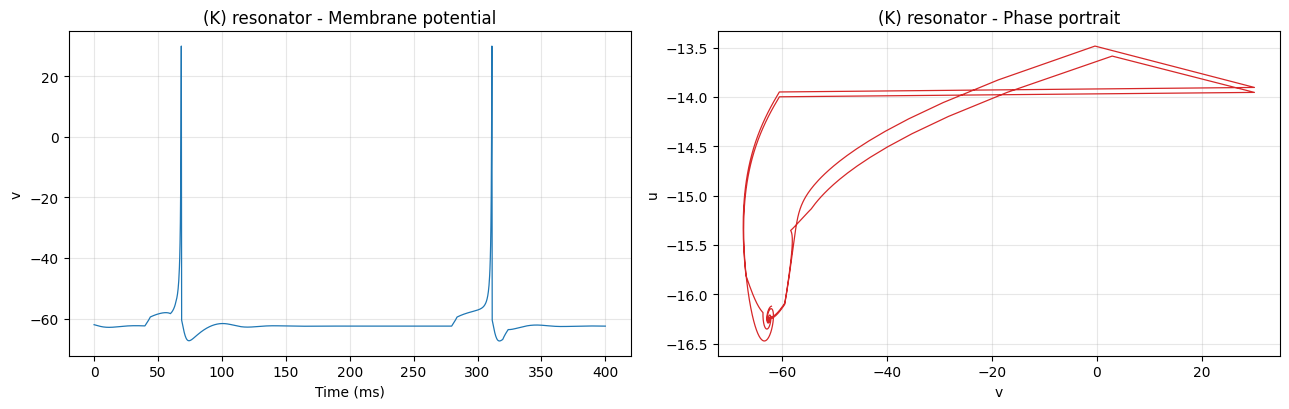

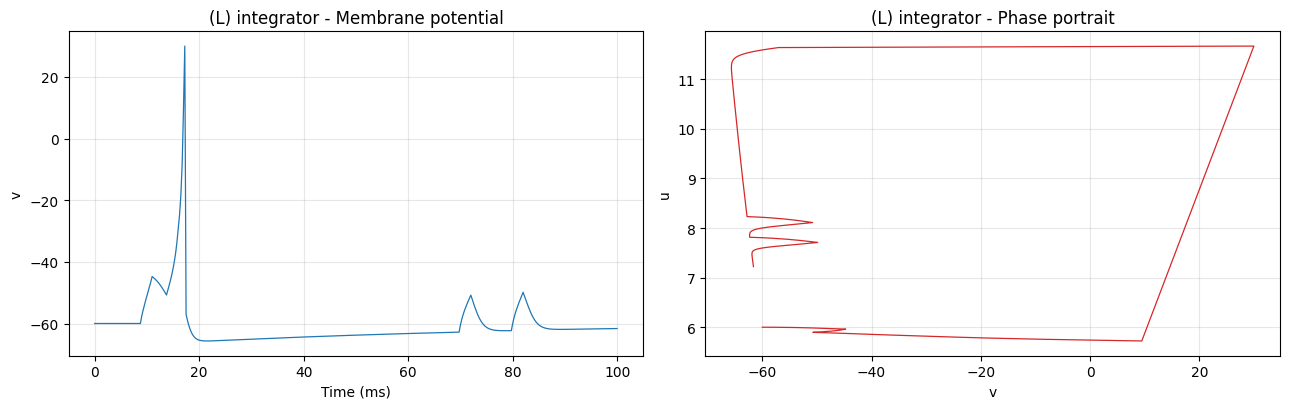

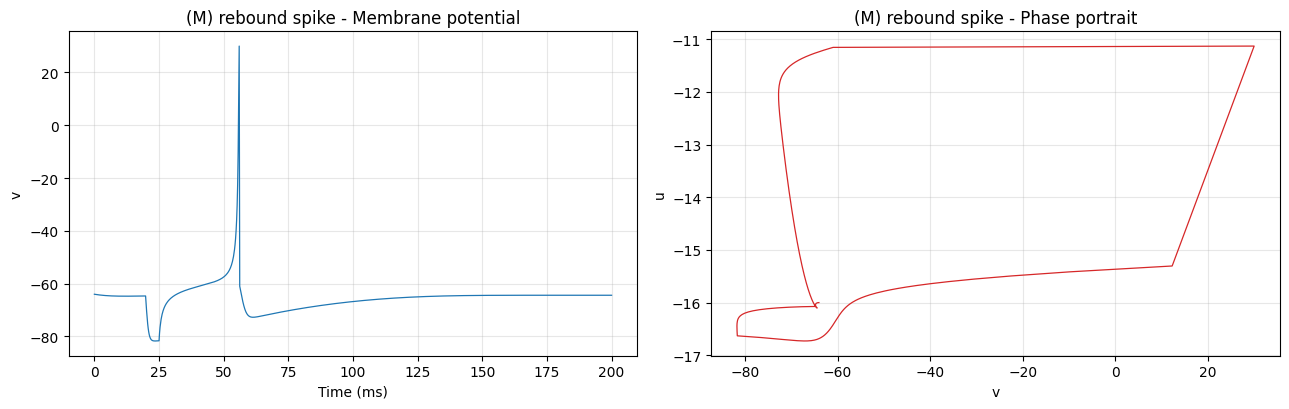

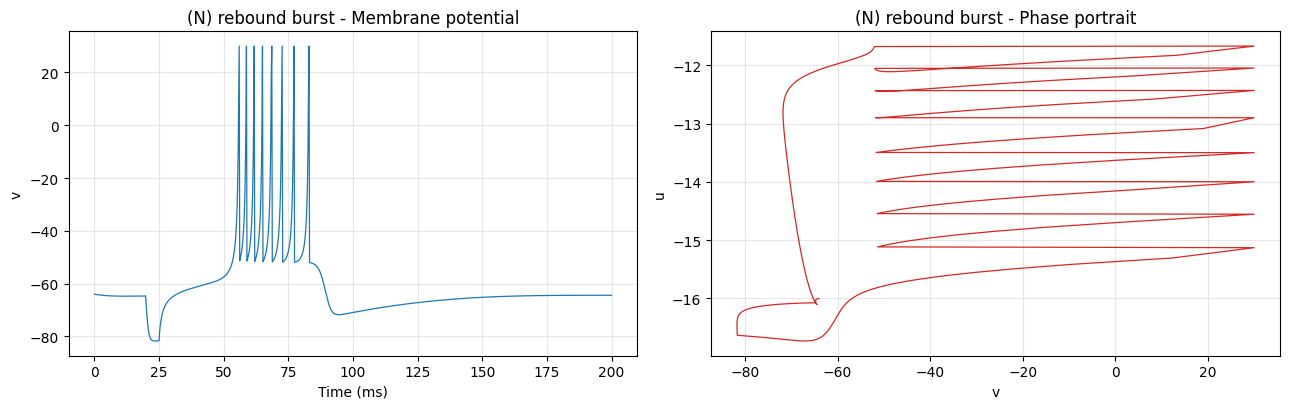

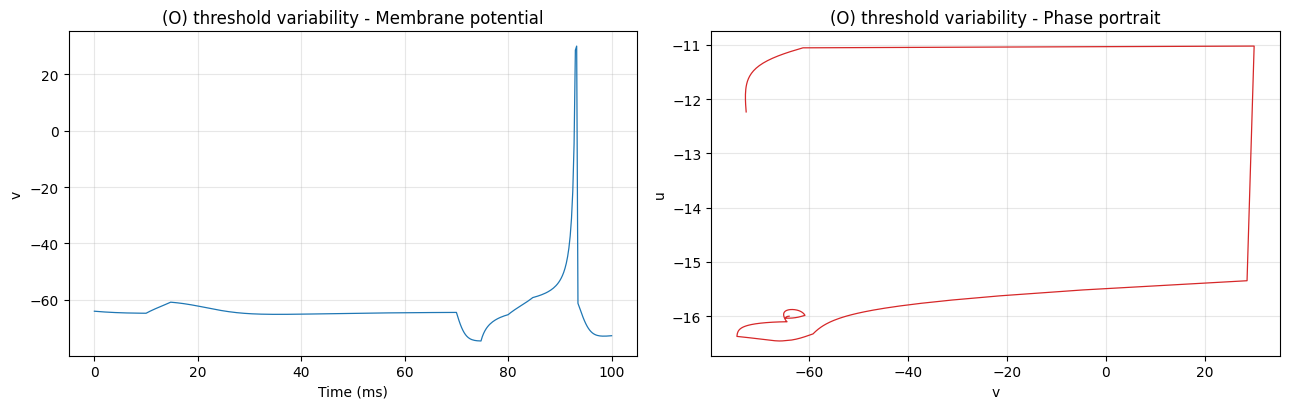

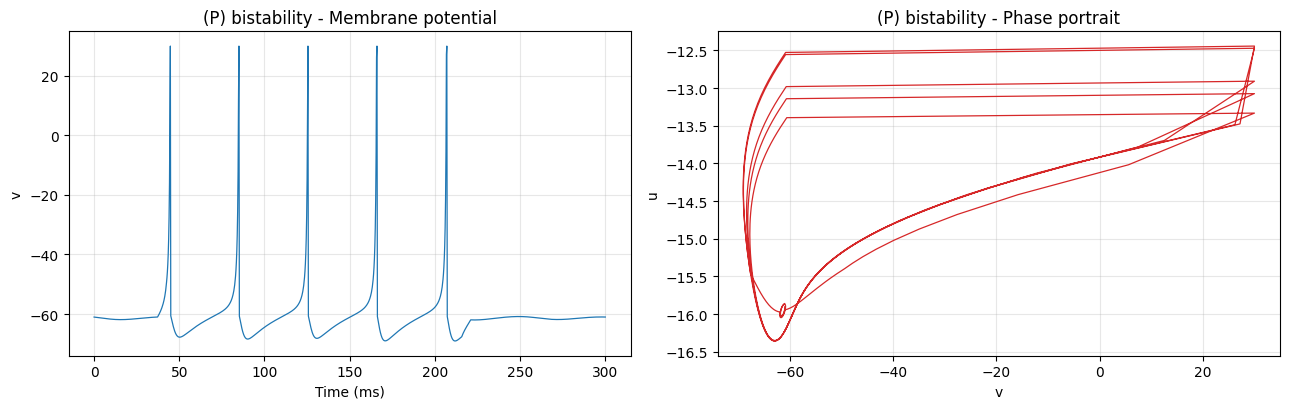

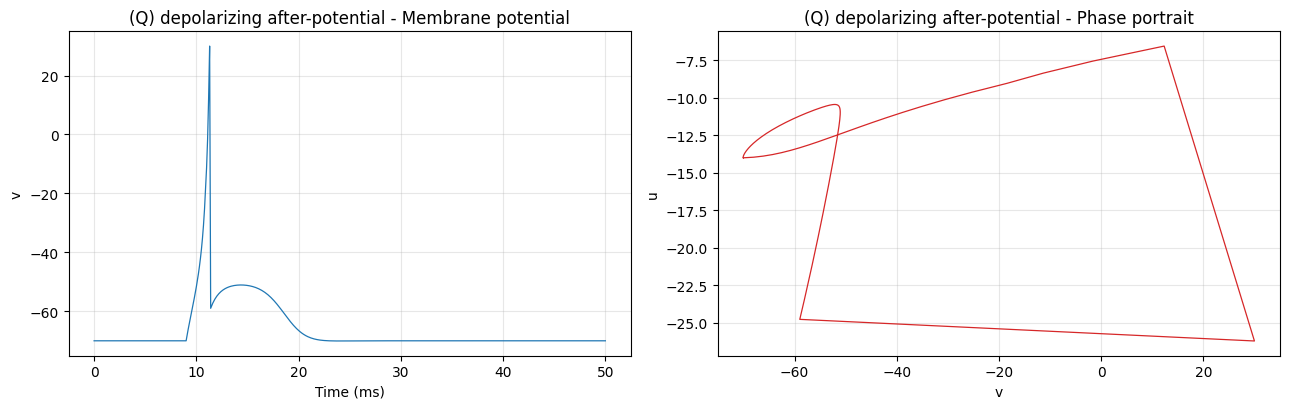

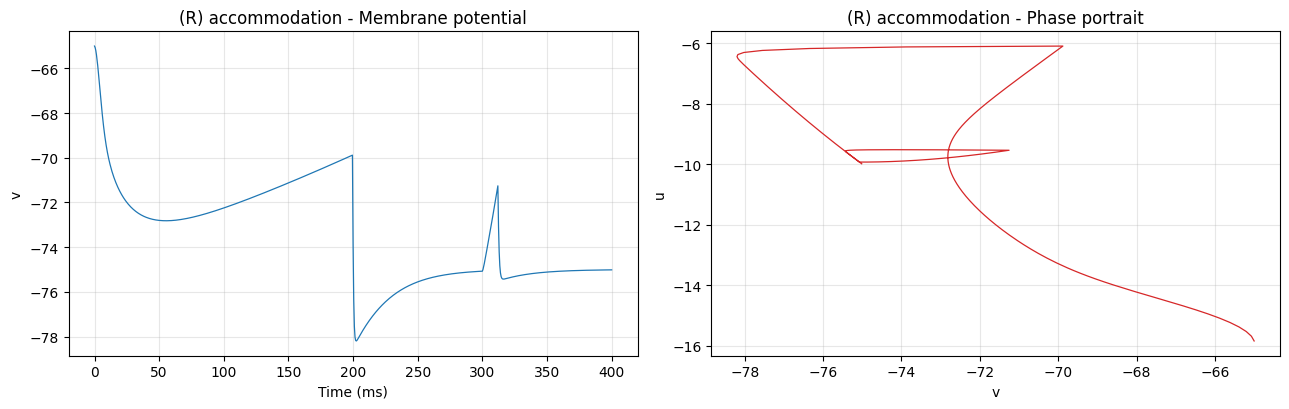

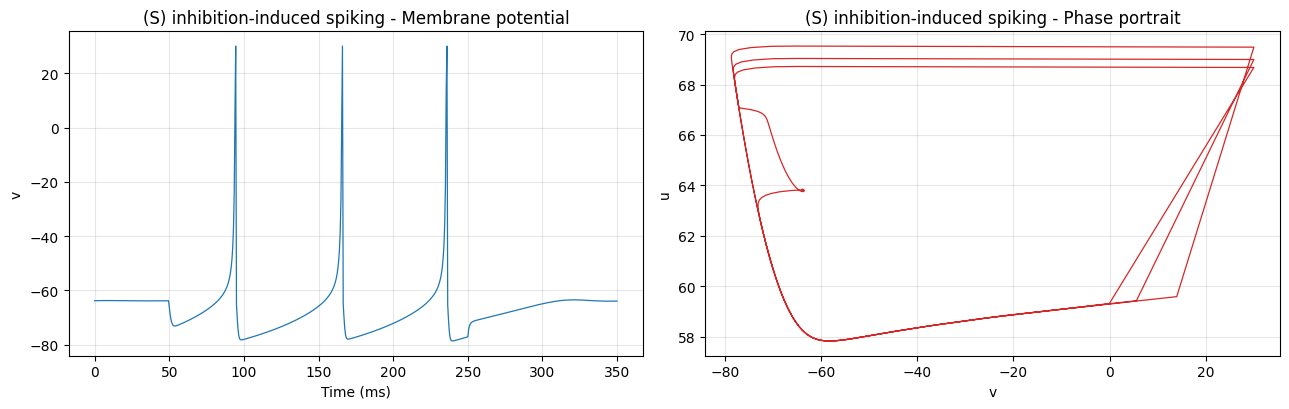

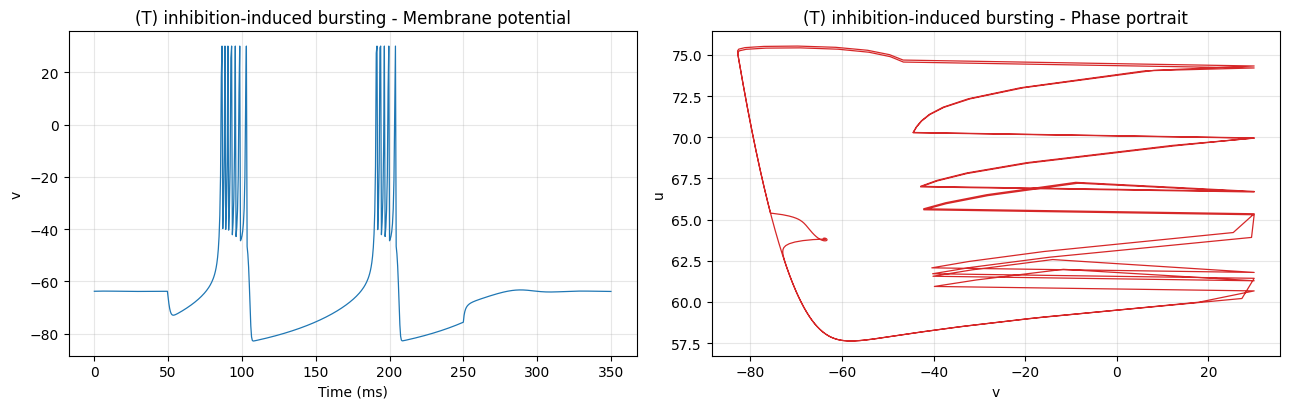

Saved 20 figures in: /Users/roberto/Developer/CNS/cns_lab_new/LAB 1-20260216/solutions/lab1/figures


In [4]:
for key, exp in experiments.items():
    trace = simulate(exp["cfg"], exp["current"], **exp["kwargs"])
    save_trace_plots(trace, exp["title"], FIG_DIR)

print(f"Saved {len(experiments)} figures in: {FIG_DIR}")
